In [1]:
import os
from pathlib import Path
BASE_DIR_PATH=Path('/kaggle/input/datasets/nalisha/netflix-movies-and-tv-shows-data-analysis')
if BASE_DIR_PATH.is_dir():
    print("Directory exists")
else:
    raise "plzz check the provided path"

Directory exists


In [2]:
import pandas as pd
import csv

file_path = "/kaggle/input/datasets/nalisha/netflix-movies-and-tv-shows-data-analysis/mymoviedb (1).csv"

# Safe loading configurations
df = pd.read_csv(
    file_path,
    engine="python",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines="skip"
)

print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns!")


Dataset successfully loaded with 9837 rows and 9 columns!


In [3]:
df.sample(2)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
7490,2018-03-07,The Night Eats the World,After waking up to find himself all alone in a...,15.977,484,6.0,fr,"Drama, Horror, Thriller",https://image.tmdb.org/t/p/original/2rR2PxT0cl...
4885,1962-09-15,Harakiri,Down-on-his-luck veteran Tsugumo Hanshirō ente...,21.293,594,8.4,ja,"Action, Drama, History",https://image.tmdb.org/t/p/original/w7pWcLaYQk...


In [4]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [6]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [7]:
df.dropna(subset=['Title'],inplace=True)

In [8]:
df = df.reset_index(drop=True)

In [9]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           1
Vote_Count           1
Vote_Average         1
Original_Language    1
Genre                2
Poster_Url           2
dtype: int64

In [10]:
df['Title'].unique()

array(['Spider-Man: No Way Home', 'The Batman', 'No Exit', ...,
       'The Offering', 'The United States vs. Billie Holiday', 'Threads'],
      shape=(9514,), dtype=object)

In [11]:
title = df['Title'].value_counts()

In [12]:
rows = df['Title'].map(title)
rows.unique()

array([1, 2, 3, 4])

In [13]:
df = df[rows == 1].reset_index(drop=True)

In [14]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9221,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9222,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9223,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9224,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [15]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           1
Vote_Count           1
Vote_Average         1
Original_Language    1
Genre                2
Poster_Url           2
dtype: int64

In [16]:
df['Original_Language'].value_counts()

Original_Language
en                                                                     7069
ja                                                                      625
es                                                                      331
fr                                                                      274
ko                                                                      164
zh                                                                      124
it                                                                      114
cn                                                                      107
ru                                                                       78
de                                                                       76
pt                                                                       35
da                                                                       25
no                                                                    

In [17]:
target_row = df[df['Original_Language'] == 'https://image.tmdb.org/t/p/original/6iXYe7AkQ1QIfMFuvXsSCT2zF7s.jpg ']

target_row

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url


In [18]:
df = df[df['Original_Language'] != 'https://image.tmdb.org/t/p/original/6iXYe7AkQ1QIfMFuvXsSCT2zF7s.jpg']
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9221,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9222,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9223,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9224,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [19]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           1
Vote_Count           1
Vote_Average         1
Original_Language    1
Genre                1
Poster_Url           1
dtype: int64

In [20]:
df[df['Original_Language'].isnull()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1021,2013-10-20,Pixie Hollow Bake Off,Tink challenges Gelata to see who can bake the...,NaN,None,None,None,None,None


In [21]:
df = df.drop(index=1021)

In [22]:
df.reset_index(drop=True)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9219,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9220,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9221,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9222,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [23]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [24]:
df['Title'].value_counts().sum()

np.int64(9224)

In [25]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9221,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9222,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9223,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9224,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [26]:
df['Genre']

0       Action, Adventure, Science Fiction
1                 Crime, Mystery, Thriller
2                                 Thriller
3       Animation, Comedy, Family, Fantasy
4         Action, Adventure, Thriller, War
                       ...                
9221                          Drama, Crime
9222                                Horror
9223             Mystery, Thriller, Horror
9224                 Music, Drama, History
9225           War, Drama, Science Fiction
Name: Genre, Length: 9224, dtype: object

In [27]:
genres_encoded = df['Genre'].str.get_dummies(sep=', ')
df = pd.concat([df, genres_encoded], axis=1)
df = df.drop('Genre', axis=1)
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Poster_Url,Action,Adventure,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,1,1,...,0,0,0,0,0,1,0,0,0,0
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,https://image.tmdb.org/t/p/original/74xTEgt7R3...,0,0,...,0,0,0,1,0,0,0,1,0,0
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,https://image.tmdb.org/t/p/original/4j0PNHkMr5...,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,1,1,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9221,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,https://image.tmdb.org/t/p/original/z81rBzHNgi...,0,0,...,0,0,0,0,0,0,0,0,0,0
9222,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,https://image.tmdb.org/t/p/original/4b6HY7rud6...,0,0,...,0,1,0,0,0,0,0,0,0,0
9223,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,https://image.tmdb.org/t/p/original/h4uMM1wOhz...,0,0,...,0,1,0,1,0,0,0,1,0,0
9224,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,0,0,...,1,0,1,0,0,0,0,0,0,0


In [28]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Poster_Url', 'Action',
       'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance',
       'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'],
      dtype='object')

In [29]:
from IPython.display import Image, display
def show_random_movie_image(dataframe):
    random_movie = dataframe.sample(n=1).iloc[0]
    
    title = random_movie['Title']
    release = random_movie['Release_Date']
    poster_url = random_movie['Poster_Url']
    
    print(f"🎬 Title: {title} ({release})")
    print(f"⭐ Rating: {random_movie['Vote_Average']} ({random_movie['Vote_Count']} votes)\n")
    
    try:
        display(Image(url=poster_url, width=250))
    except Exception as e:
        print("Could not load image. The URL might be broken or blocked.")

for i in range(5):
    show_random_movie_image(df)

🎬 Title: Marley & Me (2008-12-25)
⭐ Rating: 7.2 (3892 votes)



🎬 Title: The Jungle Bunch (2017-07-26)
⭐ Rating: 6.3 (109 votes)



🎬 Title: Evil (2003-09-16)
⭐ Rating: 7.3 (241 votes)



🎬 Title: Dorm Daze 2 (2006-12-14)
⭐ Rating: 4.3 (56 votes)



🎬 Title: Rat Race (2001-08-17)
⭐ Rating: 6.2 (1389 votes)



In [30]:
df.sample(2)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Poster_Url,Action,Adventure,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
972,2012-02-01,Chronicle,Three high school students make an incredible ...,63.591,4280,6.8,en,https://image.tmdb.org/t/p/original/xENglsVIIW...,0,0,...,0,0,0,0,0,1,0,1,0,0
3556,1982-11-12,Creepshow,"Inspired by the E.C. comics of the 1950s, Geor...",25.244,728,6.9,en,https://image.tmdb.org/t/p/original/4SoyTCEpsg...,0,0,...,0,1,0,0,0,0,0,0,0,0


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 
              'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 
              'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
numeric_cols = ['Popularity', 'Vote_Count', 'Vote_Average']
features_df = df[numeric_cols + genre_cols]
features_df.fillna(0, inplace=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)
print("Data prepared and scaled. Shape of the feature matrix:", X_scaled.shape)

Data prepared and scaled. Shape of the feature matrix: (9224, 22)


/tmp/ipykernel_16/1761398601.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_df.fillna(0, inplace=True)


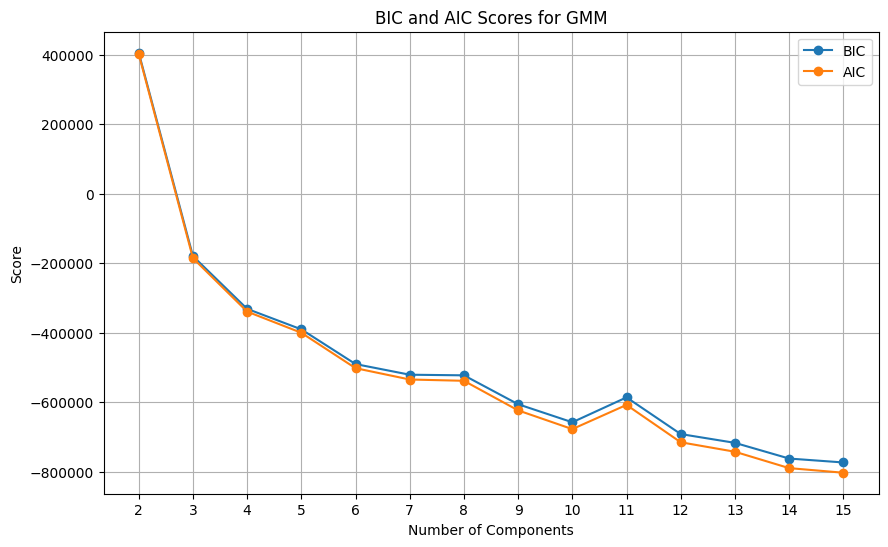

In [33]:
n_components_range = range(2, 16)
bic_scores = []
aic_scores = []
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o', label='BIC')
plt.plot(n_components_range, aic_scores, marker='o', label='AIC')
plt.title('BIC and AIC Scores for GMM')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)
plt.show()

In [34]:
OPTIMAL_COMPONENTS = 8

gmm = GaussianMixture(n_components=OPTIMAL_COMPONENTS, random_state=42)
gmm.fit(X_scaled)

cluster_labels = gmm.predict(X_scaled)

df['gmm_cluster'] = cluster_labels

print(f"Successfully fitted GMM with {OPTIMAL_COMPONENTS} components.")
print("Sample of movies with their assigned clusters:")
print(df[['Title', 'gmm_cluster']].head())

Successfully fitted GMM with 8 components.
Sample of movies with their assigned clusters:
                     Title  gmm_cluster
0  Spider-Man: No Way Home            4
1               The Batman            4
2                  No Exit            4
3                  Encanto            4
4           The King's Man            4


In [35]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Poster_Url,Action,Adventure,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,gmm_cluster
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,1,1,...,0,0,0,0,1,0,0,0,0,4
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,https://image.tmdb.org/t/p/original/74xTEgt7R3...,0,0,...,0,0,1,0,0,0,1,0,0,4
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,0,0,...,0,0,0,0,0,0,1,0,0,4
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,https://image.tmdb.org/t/p/original/4j0PNHkMr5...,0,0,...,0,0,0,0,0,0,0,0,0,4
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,1,1,...,0,0,0,0,0,0,1,1,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9221,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,https://image.tmdb.org/t/p/original/z81rBzHNgi...,0,0,...,0,0,0,0,0,0,0,0,0,1
9222,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,https://image.tmdb.org/t/p/original/4b6HY7rud6...,0,0,...,1,0,0,0,0,0,0,0,0,5
9223,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,https://image.tmdb.org/t/p/original/h4uMM1wOhz...,0,0,...,1,0,1,0,0,0,1,0,0,5
9224,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,0,0,...,0,1,0,0,0,0,0,0,0,7


In [36]:
def get_recommendations(movie_title, df, top_n=5):
    if movie_title not in df['Title'].values:
        return f"Sorry, '{movie_title}' is not in the dataset."
    movie_cluster = df[df['Title'] == movie_title]['gmm_cluster'].iloc[0]
    cluster_movies = df[df['gmm_cluster'] == movie_cluster]
    recommendations = cluster_movies[cluster_movies['Title'] != movie_title]
    recommendations = recommendations.sort_values(
        by=['Popularity', 'Vote_Average'], 
        ascending=[False, False]
    )
    return recommendations[['Title', 'Release_Date', 'Popularity', 'Vote_Average']].head(top_n)

In [37]:
print("Recommendations for 'Spider-Man: No Way Home':")
display(get_recommendations('Spider-Man: No Way Home', df))
print("-" * 50)
print("Recommendations for 'Encanto':")
display(get_recommendations('Encanto', df))
print("-" * 50)
display(get_recommendations('A Nightmare on Elm Street', df))

Recommendations for 'Spider-Man: No Way Home':


,Title,Release_Date,Popularity,Vote_Average
1,The Batman,2022-03-01,3827.658,8.1
2,No Exit,2022-02-25,2618.087,6.3
3,Encanto,2021-11-24,2402.201,7.7
4,The King's Man,2021-12-22,1895.511,7.0
5,The Commando,2022-01-07,1750.484,6.6


--------------------------------------------------
Recommendations for 'Encanto':


,Title,Release_Date,Popularity,Vote_Average
0,Spider-Man: No Way Home,2021-12-15,5083.954,8.3
1,The Batman,2022-03-01,3827.658,8.1
2,No Exit,2022-02-25,2618.087,6.3
4,The King's Man,2021-12-22,1895.511,7.0
5,The Commando,2022-01-07,1750.484,6.6


--------------------------------------------------


"Sorry, 'A Nightmare on Elm Street' is not in the dataset."

In [38]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
cluster_probabilities = gmm.predict_proba(X_scaled)
print(f"Shape of probability matrix: {cluster_probabilities.shape}")

Shape of probability matrix: (9224, 8)


In [39]:
def get_advanced_recommendations(movie_title, df, prob_matrix, top_n=5):
    if movie_title not in df['Title'].values:
        return f"Sorry, '{movie_title}' is not in the dataset."
    movie_idx = df[df['Title'] == movie_title].index[0]
    movie_vector = prob_matrix[movie_idx].reshape(1, -1)
    
    similarities = cosine_similarity(movie_vector, prob_matrix)[0]
    
    temp_df = df.copy()
    temp_df['Similarity_Score'] = similarities
    
    temp_df = temp_df.drop(movie_idx)
    
    recommendations = temp_df.sort_values(
        by=['Similarity_Score', 'Popularity', 'Vote_Average'], 
        ascending=[False, False, False]
    )
    return recommendations[['Title', 'Similarity_Score', 'Popularity', 'gmm_cluster']].head(top_n)

In [40]:
display(get_advanced_recommendations('The Batman', df, cluster_probabilities))

,Title,Similarity_Score,Popularity,gmm_cluster
0,Spider-Man: No Way Home,1.0,5083.954,4
2,No Exit,1.0,2618.087,4
3,Encanto,1.0,2402.201,4
4,The King's Man,1.0,1895.511,4
5,The Commando,1.0,1750.484,4


In [41]:
import joblib
joblib.dump(gmm, 'gmm_model.pkl')
joblib.dump(cluster_probabilities, 'cluster_probabilities.pkl')
essential_df = df[['Title', 'Release_Date', 'Popularity', 'Vote_Average', 'Poster_Url']].copy()
joblib.dump(essential_df, 'movies_metadata.pkl')
print("All deployment assets saved successfully!")

All deployment assets saved successfully!
